In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
points = {
    "P1":[0.10,0.60],"P2":[0.15,0.71],"P3":[0.08,0.90],"P4":[0.16,0.85],
    "P5":[0.20,0.30],"P6":[0.25,0.50],"P7":[0.24,0.10],"P8":[0.30,0.20]
}

In [6]:
m1 = np.array(points["P1"])
m2 = np.array(points["P8"])


In [7]:
assign = {}
for name, coord in points.items():
    pt = np.array(coord)
    d1 = np.linalg.norm(pt - m1)
    d2 = np.linalg.norm(pt - m2)
    assign[name] = 1 if d1 <= d2 else 2
    

In [10]:
C1 = [p for p, v in assign.items() if v==1]
C2 = [p for p, v in assign.items() if v==2]

In [14]:
print("Cluster C1 (assigned points):", C1)
print("Cluster C2 (assigned points):", C2)
print("\n1) P6 belongs to Cluster C{}".format(assign['P6']))
print("2) Population of cluster around m2 (C2):", len(C2), "->", C2)

Cluster C1 (assigned points): ['P1', 'P2', 'P3', 'P4', 'P6']
Cluster C2 (assigned points): ['P5', 'P7', 'P8']

1) P6 belongs to Cluster C1
2) Population of cluster around m2 (C2): 3 -> ['P5', 'P7', 'P8']


In [15]:
new_m1 = np.mean([points[p] for p in C1], axis=0)
new_m2 = np.mean([points[p] for p in C2], axis=0)
print("\n3) Updated centroids:")
print(" new m1 = ({:.6f}, {:.6f})".format(new_m1[0], new_m1[1]))
print(" new m2 = ({:.6f}, {:.6f})".format(new_m2[0], new_m2[1]))


3) Updated centroids:
 new m1 = (0.148000, 0.712000)
 new m2 = (0.246667, 0.200000)


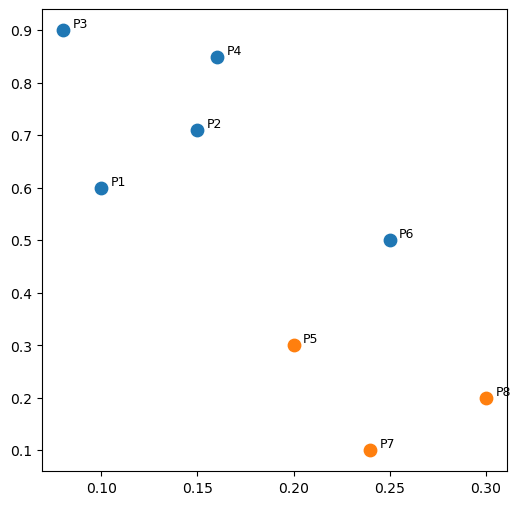

In [16]:
plt.figure(figsize=(6,6))
for name, (x,y) in points.items():
    color = 'C0' if assign[name]==1 else 'C1'
    plt.scatter(x, y, color=color, s=80)
    plt.text(x+0.005, y+0.005, name, fontsize=9)

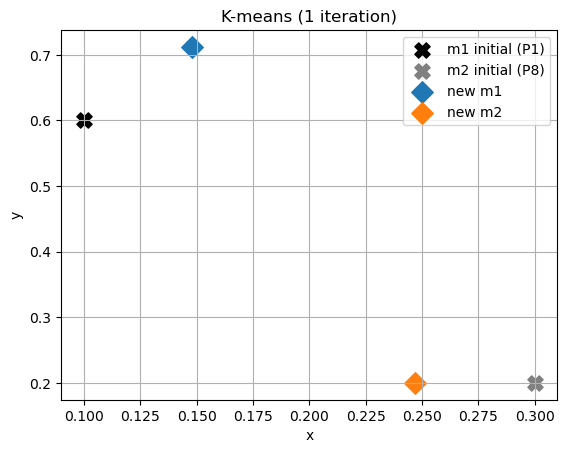

In [17]:
plt.scatter(m1[0], m1[1], marker='X', color='k', s=120, label='m1 initial (P1)')
plt.scatter(m2[0], m2[1], marker='X', color='gray', s=120, label='m2 initial (P8)')
plt.scatter(new_m1[0], new_m1[1], marker='D', color='C0', s=120, label='new m1')
plt.scatter(new_m2[0], new_m2[1], marker='D', color='C1', s=120, label='new m2')

plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.title('K-means (1 iteration)')
plt.grid(True); plt.show()